# **Decoding Hit Songs: A Spotify Data-Driven Prediction Model**:
# **Haeun Lee**


# **Introduction and Background**

In the digital age, music streaming platforms have become the primary medium through which listeners access and discover music. Among these platforms, Spotify stands out not only for its vast catalog of songs but also for its sophisticated use of data analytics to enhance user engagement. By tracking user interactions and analyzing audio features, Spotify delivers personalized recommendations and generates curated playlists that align closely with individual preferences.

This project focuses on analyzing a comprehensive Spotify dataset obtained from Kaggle, which contains over 100,000 tracks accompanied by a variety of features. These features include both quantitative audio attributes, such as danceability, energy, valence, loudness, tempo, and speechiness, as well as metadata like artist names, song titles, genres, and popularity scores. In addition, the dataset includes binary indicators such as whether a track is explicit, offering further dimensions for exploration.

The overarching aim of this project is to investigate the characteristics that drive a song’s popularity on the platform. We begin by performing data cleaning and preprocessing to ensure the dataset is suitable for analysis. This is followed by an in-depth exploratory data analysis (EDA) phase where we identify key trends, outliers, and correlations among variables. For instance, we examine how different genres correlate with popularity, whether specific audio features are predictive of success, and how the explicitness of a track might affect listener engagement.

In the latter stages, we employ various machine learning models to predict a song’s popularity based on its features. By comparing model performances, we aim to identify the most effective approach for making these predictions. Ultimately, this project not only provides insight into the dynamics of music consumption on Spotify but also showcases the application of data science techniques in a real-world, entertainment-focused context.

**Import Packages**

In [ ]:
# import packages
import json
import glob
import pandas as pd
import numpy as np
import datetime as dt
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from google.colab import drive
from sklearn.model_selection import train_test_split
from collections import Counter
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set up the Kaggle credentials
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d maharshipandya/-spotify-tracks-dataset
!unzip \*-spotify-tracks-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
License(s): ODbL-1.0
Archive:  -spotify-tracks-dataset.zip
  inflating: dataset.csv             


In [ ]:
import os
os.listdir()

['.config',
 'dataset.csv',
 'drive',
 '-spotify-tracks-dataset.zip',
 'sample_data']

# **Data Wrangling and Initial Analysis**

In [ ]:
# Load the dataset
spotify_data = pd.read_csv('dataset.csv')

# Display the first few rows
spotify_data.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
# Check basic information about the dataset
print("Dataset shape:", spotify_data.shape)
print("\nColumns in the dataset:")
print(spotify_data.columns.tolist())

# Basic statistics
spotify_data.describe()

# Check for missing values
print("\nMissing values in each column:")
print(spotify_data.isnull().sum())

# change explicit to 1 for True and 0 for False
spotify_data['explicit'] = spotify_data['explicit'].astype(int)

Dataset shape: (114000, 21)

Columns in the dataset:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Missing values in each column:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [ ]:
# check types of each column to ensure that all of the features we would be using moving forward is in int or float formatting
# will not be using Unnamed:0 , track_id, artists, album_name, track_name columns as they as distinct to the songs.
spotify_data.dtypes

,0
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,int64
danceability,float64
energy,float64


In [ ]:
# check types of track_genre
no_genres = len(spotify_data['track_genre'].unique())
print("There are", no_genres, "different genres covered in this data set.")
spotify_data['track_genre'].unique()

There are 114 different genres covered in this data set.


array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

# **Exploratory Data Analysis**

**1. Distribution of Track Popularity**

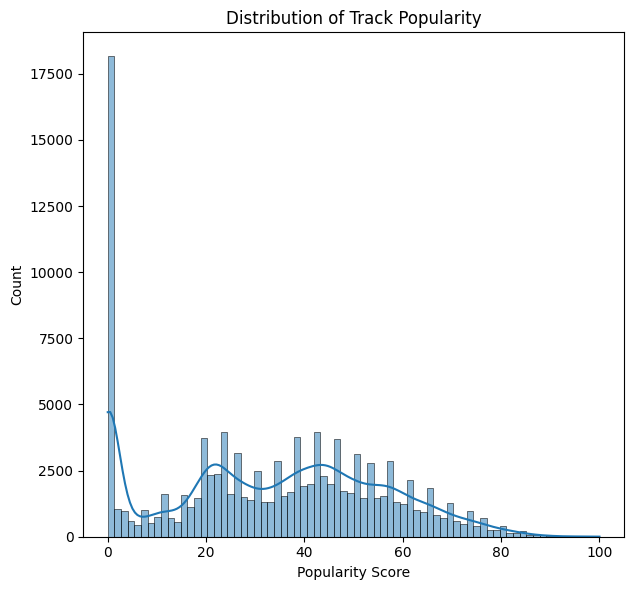

In [ ]:
plt.figure(figsize=(12, 6))

# Distribution of track popularity
plt.subplot(1, 2, 1)
sns.histplot(spotify_data['popularity'], kde=True)
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# get summary statistics of the popularity scores in this data set
spotify_data['popularity'].describe()

,popularity
count,114000.000000
mean,33.238535
std,22.305078
min,0.000000
25%,17.000000
50%,35.000000
75%,50.000000
max,100.000000


The majority of the songs in this data set have quite a low popularity score, with the highest peak being close to 0. The data set seems skew more towards a lower poplarity score as even at the 75% percentile, the popularity score is only a 50.

**2. Top 10 Most Frequent Artists**

<ipython-input-15-f97b977d61ba>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')


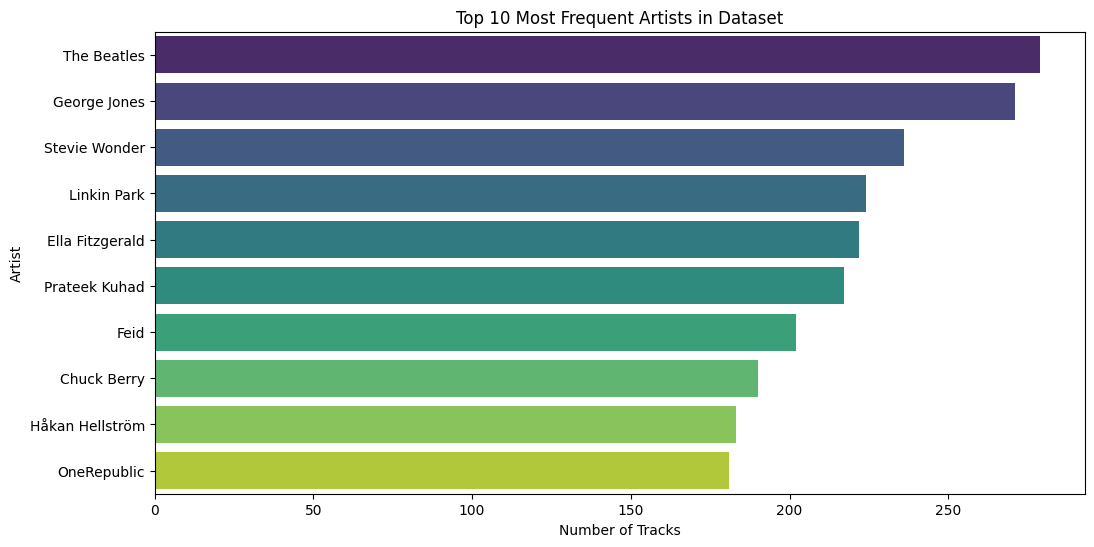

In [ ]:
top_artists = spotify_data['artists'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')
plt.title("Top 10 Most Frequent Artists in Dataset")
plt.xlabel("Number of Tracks")
plt.ylabel("Artist")
plt.show()

Here we can visualize who the top 10 artists are in our dataset in terms of number of tracks. We see popular bands such as The Beatles or Linkin Park and legendary singer Stevie Wonder.

**3. Relationship Between Track Duration and Popularity**

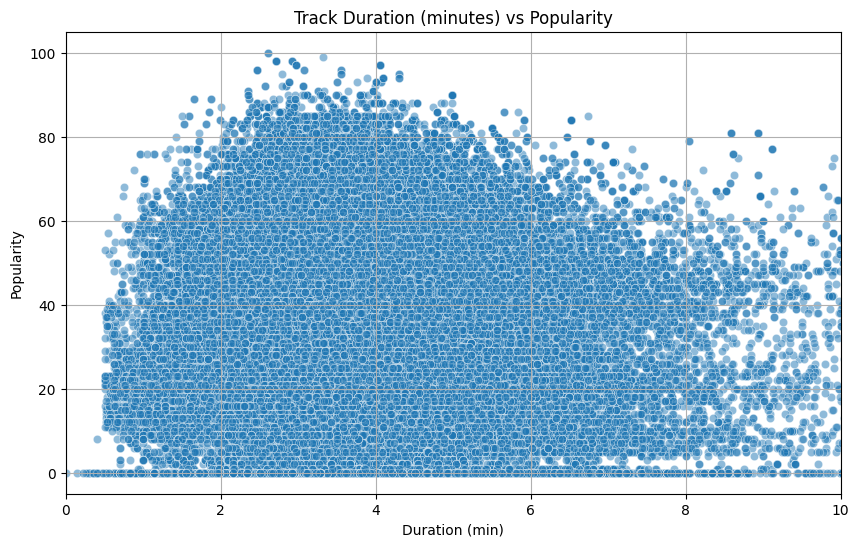

In [ ]:
# converting the duration from ms to minutes
duration_min= spotify_data['duration_ms']/60000
plt.figure(figsize=(10, 6))
sns.scatterplot(data=spotify_data, x=duration_min, y='popularity', alpha=0.5)
plt.title("Track Duration (minutes) vs Popularity")
plt.xlabel("Duration (min)")
plt.ylabel("Popularity")
plt.grid(True)
plt.xlim(0,10)
plt.show()


Overall, there does not seem to be a strong relationship between the duration of the song (in minutes) and the popularity of the song.

We do note that most songs fall between a duration of 2-5 minutes.

**4. Number of rows for each genre of music**

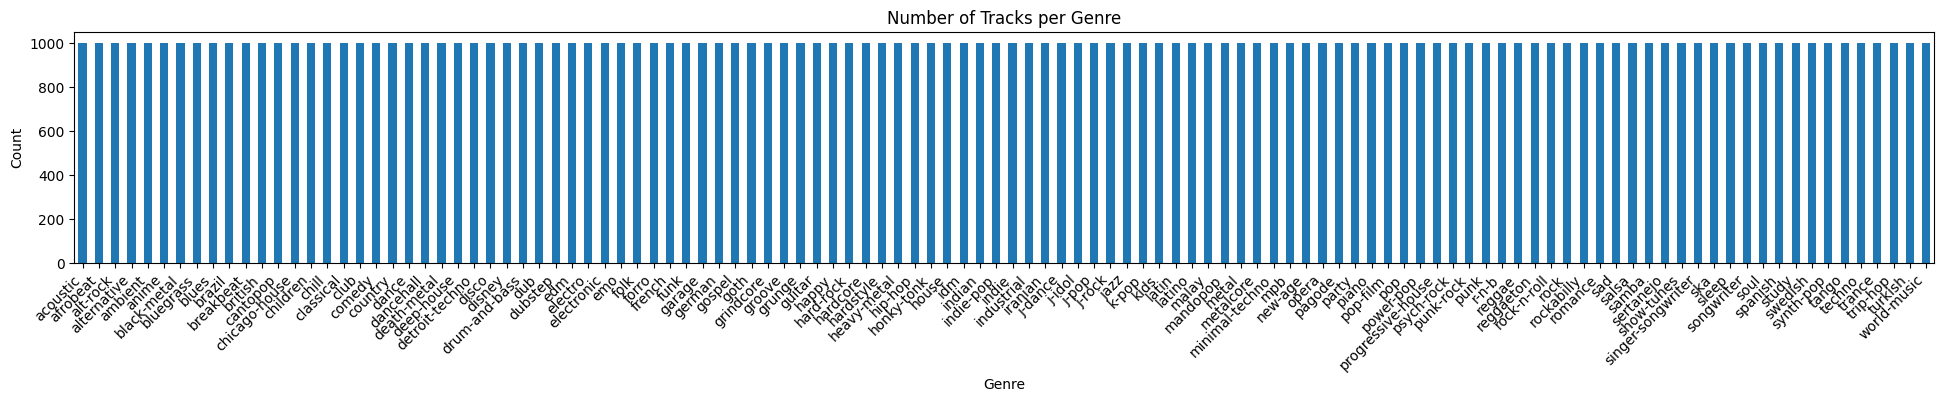

In [ ]:
genre_counts = spotify_data['track_genre'].value_counts()

plt.figure(figsize=(24, 3))
genre_counts.plot(kind='bar')

plt.title('Number of Tracks per Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

Each genre has 1000 rows, meaning that this data set is very balanced and will avoid bias towards genres that are more common!


## Analyzing relationship between Popularity and Energy of the song

We'll categorize energy in three tiers:


*   Low Energy: below 0.499
*   Medium Energy: 0.5-0.699
*   High Energy: above 0.75






In [ ]:
#creating energy tiers for the plot
spotify_data['energy_tier'] =spotify_data['energy'].apply(lambda x: "Low" if x < 0.499 else("High" if x>0.75 else "Medium"))


<ipython-input-18-fc11f1ab39ea>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='energy_tier', y='popularity', data=popularity_by_energy, palette='viridis')


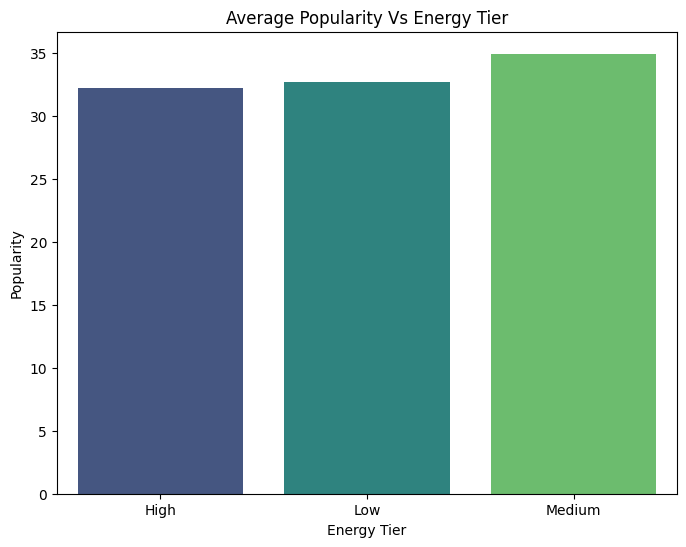

,energy_tier,popularity
0,High,32.222958
1,Low,32.725823
2,Medium,34.953674


In [ ]:
# plotting energy tier vs popularity
popularity_by_energy = spotify_data.groupby('energy_tier')['popularity'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(x='energy_tier', y='popularity', data=popularity_by_energy, palette='viridis')
plt.title("Average Popularity Vs Energy Tier")
plt.xlabel("Energy Tier")
plt.ylabel("Popularity")
plt.show()

popularity_by_energy

Analysis: Based on the aggregated data, the plot suggests that the average popularity for songs across High, Medium, and Low energy tiers is very similar (with averages of about 62.43, 62.97, and 60.63, respectively).

These small differences indicate that,energy level of a song alone does not appear to be a strong predictor of its popularity. While energy might play a role in the musical experience, other factors likely have a more significant impact on what makes a song popular.

## Analyzing relationship between Popularity and Danceability of the song

We'll now analyze the realtionshio between danceability and song popularity.

We're breaking the danceability of a song into three tiers:


*   Low Danceability: below 0.300
*   Medium Danceabiluty: 0.31-0.70
*   High Danceability: above 0.701




In [ ]:
#creating dance tiers for the plot
spotify_data['dance_tier'] =spotify_data['danceability'].apply(lambda x: "Low" if x < 0.300 else("High" if x>0.701 else "Medium"))


<ipython-input-20-8c0c99acadad>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dance_tier', y='popularity', data=popularity_by_dance, palette='viridis')


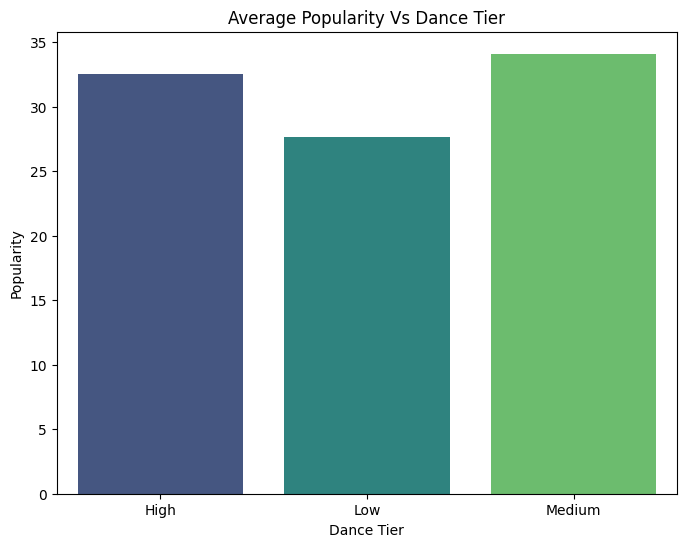

,dance_tier,popularity
0,High,32.561292
1,Low,27.676281
2,Medium,34.116278


In [ ]:
# plotting dance tier vs popularity
popularity_by_dance = spotify_data.groupby('dance_tier')['popularity'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(x='dance_tier', y='popularity', data=popularity_by_dance, palette='viridis')
plt.title("Average Popularity Vs Dance Tier")
plt.xlabel("Dance Tier")
plt.ylabel("Popularity")
plt.show()

popularity_by_dance

**Conclusion**: Our analysis explored whether energy and danceability—two core audio features—could independently explain a track's popularity. By categorizing each into low, medium, and high tiers and comparing their average popularity scores, we found only minor differences between groups.

While it may seem intuitive that more energetic or danceable songs would be more popular, our results suggest that these features alone do not strongly predict popularity. This indicates that song popularity is influenced by a more complex combination of factors, reinforcing the need for multivariable models to accurately capture these relationships.



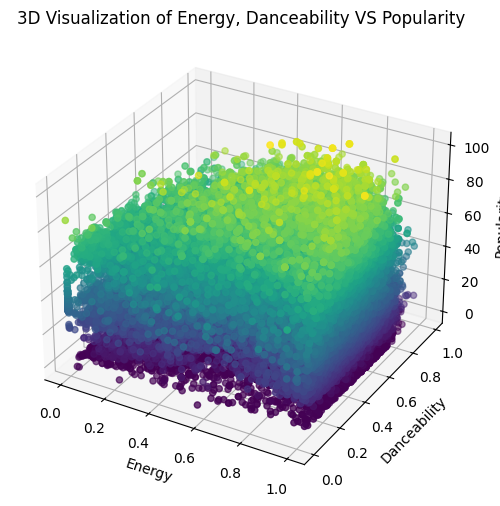

In [ ]:
# creating a 3D plot to visualize the features

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection='3d')

#setting the axes
x= spotify_data['energy']
y=spotify_data['danceability']
z = spotify_data['popularity']

ax.scatter(x,y,z, c=z)
ax.set_xlabel("Energy")
ax.set_ylabel('Danceability')
ax.set_zlabel('Popularity')
ax.set_title('3D Visualization of Energy, Danceability VS Popularity')

plt.show()

This 3D scatter allows us to visualize both danceability and energy of a song with regards to its popularity.

We note that data points cluster more densely in the mid-energy and mid-danceability ranges. This confirms our original conclusion that these two features alone are poor predictors of a song popularity.

In [ ]:
#removing columns we added for the previous part
spotify_data = spotify_data.drop(columns= ['energy_tier', 'dance_tier'])

# **Modelling**

Having concluded that single features alone (like energy or danceability) cannot help us predict a song's popularity level, we decided to build and try a variety of predictive models.

We started by treating popularity as a continuous value and trying regression models. We gauged each model's capacity to predict popularity by comparing their R² and RMSE values.


## Trying XGBoost models to find features of highest importance to predict popularity


In [ ]:
## XGBoost model with all features
from xgboost import XGBRegressor

# Define features (X) and target variable (y)
X = spotify_data_clean[features]
y = spotify_data_clean['popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train the model
model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 383.00
R² Score: 0.22


In [ ]:
# try different combinations of parameters

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

search = RandomizedSearchCV(XGBRegressor(n_jobs=-1, random_state=42), param_grid, scoring='r2', n_iter=10, cv=3)
search.fit(X_train, y_train)

best_model = search.best_estimator_

print(best_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)


In [ ]:
## XGBoost model (best_model after hyperparameter tuning) with all features

y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 288.62
R² Score: 0.42


XGB model performed a bit better with hyperparameter tuning, however, the r^2 value still is not great.

In [ ]:
## get important features
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_features = importance_df['Feature'].head(15).tolist()
X_top = spotify_data_clean[top_features]

In [ ]:
top_features
## meaning that genre itself is most informative

['genre_romance',
 'genre_iranian',
 'genre_pop-film',
 'genre_latin',
 'genre_detroit-techno',
 'genre_chicago-house',
 'genre_k-pop',
 'genre_chill',
 'genre_sad',
 'genre_classical',
 'genre_jazz',
 'genre_emo',
 'genre_grindcore',
 'genre_anime',
 'genre_kids']

The top 15 features of the XGB model are all genres. Therefore, as we've seen in the linear regression models as well, it seems like the genre of the songs themselves are the most predictive of their popularity. Moving forward, we will train the XGB model by genre so that we are able to get the features of the highest importance besides the genres themselves.


In [ ]:
from xgboost import XGBRegressor


# train XGB by individual genres
results = []
columns = spotify_data.columns.tolist()


for genre in popular_genres:
    genre_df = spotify_data_clean2[spotify_data_clean2['track_genre'] == genre]

    # get X and y data
    X = genre_df[features2]
    y = genre_df['popularity']

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train model
    model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # look at top 5 most important features
    importances = model.feature_importances_
    feature_names = X.columns
    top_features = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(5)


    results.append({
        'genre': genre,
        'samples': len(genre_df),
        'MSE': mse,
        'R²': r2,
        'top_features': top_features.index.tolist(),
        'importance_scores': top_features.values.tolist()
    })


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by = 'R²', ascending = False).reset_index(drop=True)
results_df

,genre,samples,MSE,R²,top_features,importance_scores
0,sleep,1000,143.037155,0.592296,"[valence, loudness, danceability, time_signatu...","[0.17207171022891998, 0.16812200844287872, 0.1..."
1,hip-hop,1000,546.836792,0.481246,"[explicit, acousticness, loudness, danceabilit...","[0.1576293706893921, 0.14338070154190063, 0.09..."
2,pop,1000,629.857605,0.474151,"[acousticness, tempo, liveness, energy, instru...","[0.10421044379472733, 0.10064385831356049, 0.0..."
3,j-pop,1000,274.831268,0.465211,"[energy, acousticness, time_signature, danceab...","[0.19109079241752625, 0.10644826292991638, 0.0..."
4,rockabilly,1000,190.508728,0.421209,"[acousticness, loudness, liveness, energy, dan...","[0.1662837266921997, 0.15583372116088867, 0.11..."
...,...,...,...,...,...,...
109,electronic,1000,315.571014,-0.139012,"[acousticness, valence, speechiness, tempo, in...","[0.09697796404361725, 0.0912688747048378, 0.08..."
110,black-metal,1000,101.109222,-0.167223,"[explicit, loudness, liveness, acousticness, d...","[0.11949626356363297, 0.08736912906169891, 0.0..."
111,idm,1000,117.224319,-0.174852,"[instrumentalness, tempo, energy, danceability...","[0.10096656531095505, 0.09184370189905167, 0.0..."
112,gospel,1000,17.146461,-0.295050,"[tempo, duration_ms, mode, valence, danceability]","[0.24562498927116394, 0.11586109548807144, 0.0..."


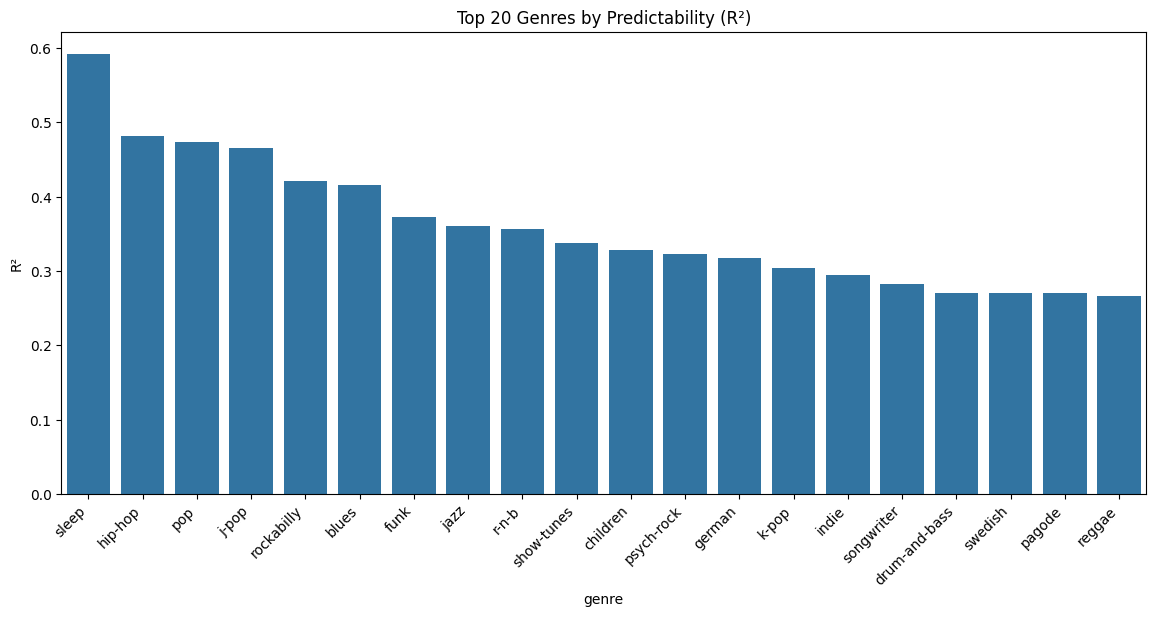

In [ ]:
# plot the top 20 r^2 values and their genres
top_20 = results_df.sort_values(by='R²', ascending=False).head(20)


plt.figure(figsize=(14, 6))
sns.barplot(data=top_20, x='genre', y='R²')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Genres by Predictability (R²)')
plt.show()

The genre with the highest r^2 value is sleep with an r^2 value of 0.59. This isn't very high, meaning our XGB regression per genre isn't a great model for this problem.

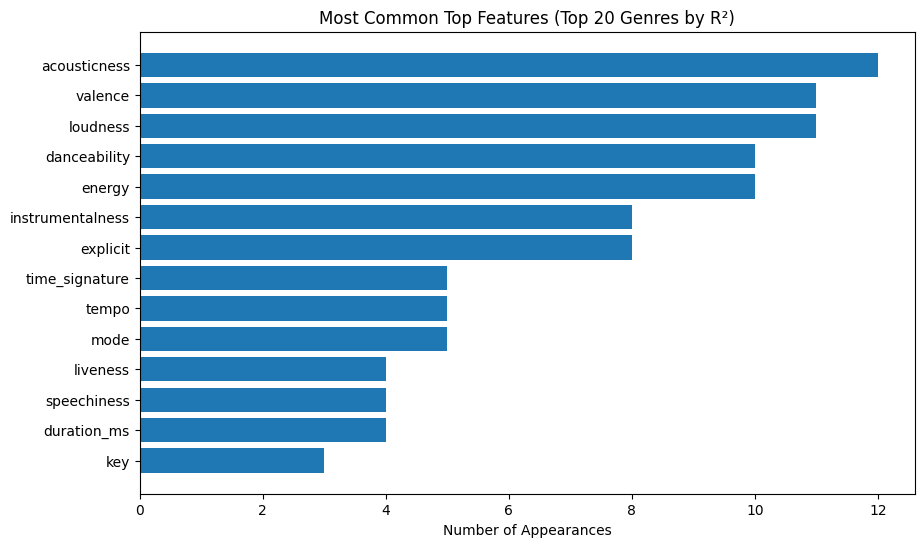

In [ ]:
# plot the most common top features in the top 20

from collections import Counter

top_20_features = sum(top_20['top_features'].tolist(), [])
feature_counts_top_20 = Counter(top_20_features)

top_20_feature_df = pd.DataFrame(feature_counts_top_20.items(), columns=['feature', 'count'])
top_20_feature_df = top_20_feature_df.sort_values(by='count', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(top_20_feature_df['feature'][::-1], top_20_feature_df['count'][::-1])
plt.xlabel("Number of Appearances")
plt.title("Most Common Top Features (Top 20 Genres by R²)")
plt.show()

Looking at the top 20 genres with the highest r^2 values, we can see that they do share some common top features.

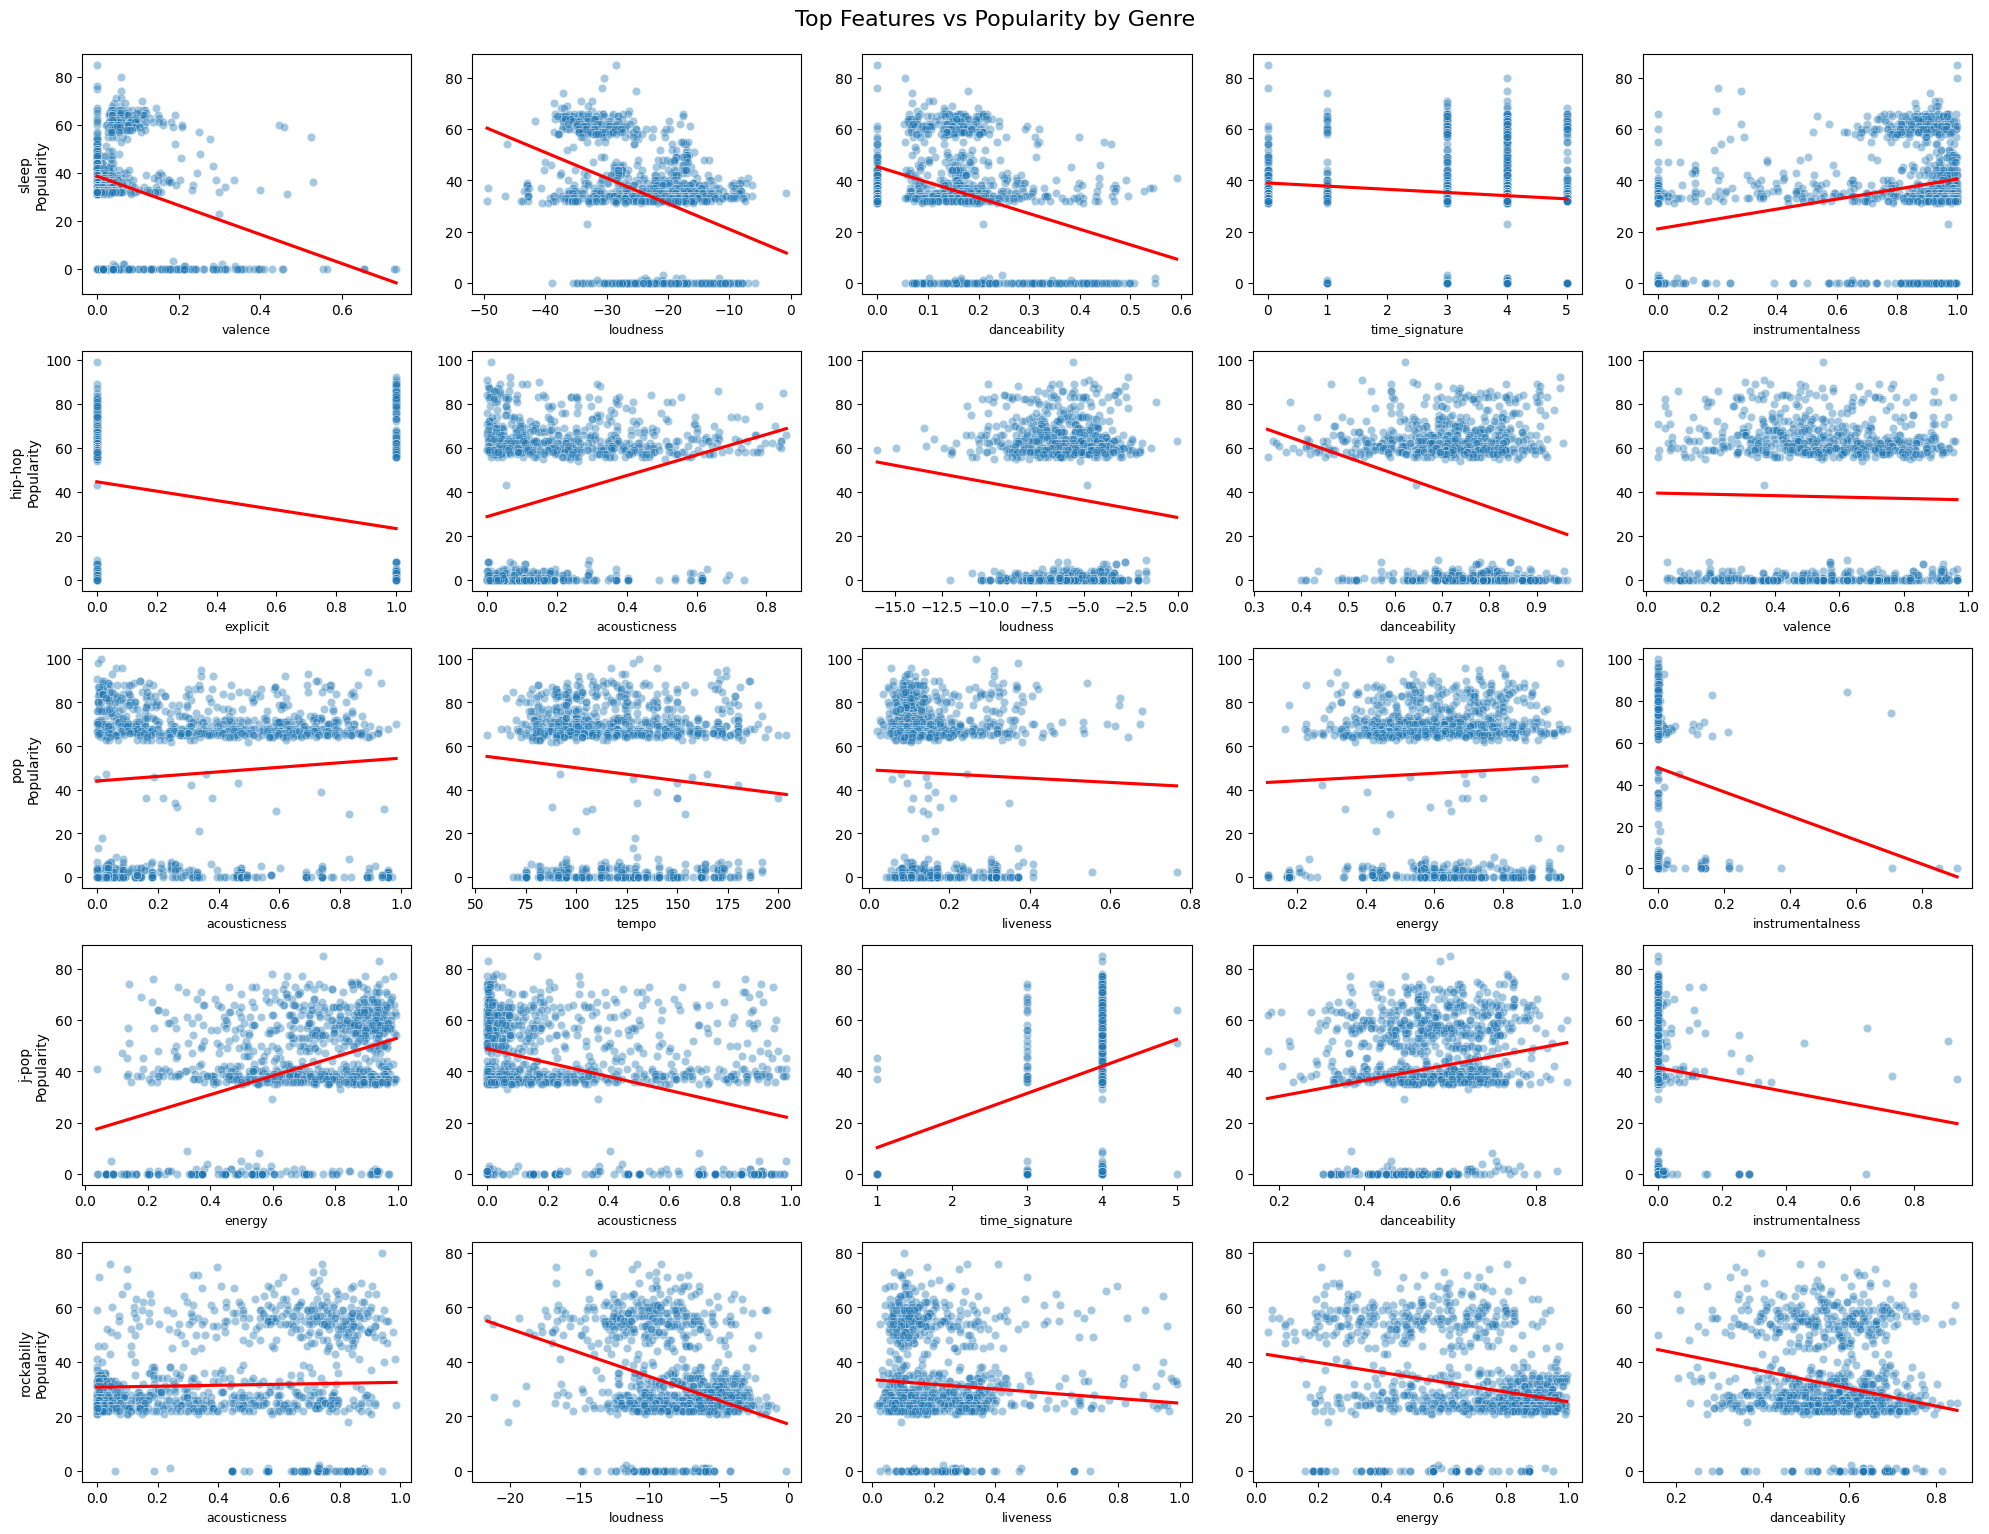

In [ ]:
top_genres_df = results_df.sort_values(by='R²', ascending=False).head(5)


# Determine how many features to plot per genre
top_n_genres = 5
top_n_features = 5

# Create subplot grid (rows = genres, columns = up to N features)
fig, axes = plt.subplots(nrows=top_n_genres, ncols=top_n_features, figsize=(top_n_features * 4, top_n_genres * 3), squeeze=False)

for row_idx, (_, genre_row) in enumerate(top_genres_df.iterrows()):
    genre = genre_row['genre']
    genre_df = spotify_data[spotify_data['track_genre'] == genre].dropna()
    top_feats = genre_row['top_features'][:top_n_features]

    for col_idx in range(top_n_features):
        ax = axes[row_idx][col_idx]

        if col_idx >= len(top_feats):
            ax.axis('off')
            continue

        feat = top_feats[col_idx]
        if feat not in genre_df.columns:
            ax.axis('off')
            continue

        # Plot data and regression line
        sns.scatterplot(data=genre_df, x=feat, y='popularity', alpha=0.4, ax=ax)
        sns.regplot(data=genre_df, x=feat, y='popularity', scatter=False, ax=ax, color='red', ci=None)

        # Always show the feature name as xlabel
        ax.set_xlabel(feat, fontsize=9)

        # Label genre on the leftmost y-axis
        if col_idx == 0:
            ax.set_ylabel(f"{genre}\nPopularity", fontsize=10)
        else:
            ax.set_ylabel("")

plt.tight_layout()
plt.suptitle("Top Features vs Popularity by Genre", fontsize=16, y=1.02)
plt.show()

Based on these plots, we can clearly see that we should approach this problem as a classifcation problem. When plotting the top genres with the highest r^2 values and their top 5 most important features, we can a clear threshold in the y axis (popularity) and see that popularity scattered across a popularity score of 0 to 100 but rather make usually 2 distinct clusters (high and low). Therefore, it makes sense why the XGB regression model wasn't working very well. We will now try to approach this problem as a classification problem!

## **Classification Modelling**

Based on the previous section, we refined our objective. We now aim to predict a binary outcome (whether a track becomes a “hit” or not), which is why we opted to frame the problem as a classification task and apply classification models than regression models.

We defined 5 popularity bins based on the popularity scores, and labeled every song accordingly.

We then evaluated a series of classification models including logistic regression, random forests, gradient boosting, SVM, and MLP to identify which model best distinguishes hit songs.

In [ ]:
# copying df
spotify_data_clean = spotify_data.copy()

# creating bins
spotify_data_clean['popularity_bin'] = pd.cut(
    spotify_data_clean['popularity'],
    bins= [0, 25, 50, 75, 100],
    labels=[f"bin_{i}" for i in range(4)],
    include_lowest = True
)

#one-hot encoding of track_genre
spotify_data_clean = pd.get_dummies(spotify_data_clean, columns=['track_genre'], prefix='genre', dtype = int)

# Drop the unnecessary 'Unnamed: 0' column
spotify_data_clean = spotify_data_clean.drop(columns=['Unnamed: 0'])

# Define features and target variable
# removing track_id, artists, album_name, and track_name bc it's specific to that row!
features = spotify_data_clean.columns.tolist()
for col in ['popularity_bin','genre_pop','popularity', 'track_id', 'artists','album_name','track_name']:
    features.remove(col)

# Drop rows with missing values in the selected columns
spotify_data_clean = spotify_data_clean.dropna(subset=features + ['popularity'])

# Define features (X) and target variable (y)
X= spotify_data_clean[features]
y= spotify_data_clean['popularity_bin']

#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### (a) Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#initialize, fit and predict using Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

# getting accuracy score
lr_acc = accuracy_score(y_pred, y_test)

print("Accuracy: %.0f%%"% (lr_acc*100))

Accuracy: 39%


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# creating dataframe with feature and corresponding coefficient
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False).reset_index(drop=True)

# sorting by magnitude
coefficients=(coefficients.assign(Magnitude=coefficients['Coefficient'].abs()))

print(coefficients)

              Feature   Coefficient     Magnitude
0               tempo  4.490552e-03  4.490552e-03
1            loudness -3.162869e-03  3.162869e-03
2                 key  4.731840e-04  4.731840e-04
3    instrumentalness  3.196302e-04  3.196302e-04
4      time_signature  2.673383e-04  2.673383e-04
..                ...           ...           ...
122      danceability -2.404452e-06  2.404452e-06
123          liveness  1.713767e-06  1.713767e-06
124       genre_malay -1.490868e-06  1.490868e-06
125       duration_ms  1.371071e-06  1.371071e-06
126        genre_funk -5.269036e-07  5.269036e-07

[127 rows x 3 columns]


**Results**:

We see that Logistic Regression only achieved an accuracy of 39% which is quite low.

By looking at our features and their coefficients, we see that tempo has a highest positive coefficient indicating that faster songs are easier to classify.
Loudness on the other hand has the largest negative coefficient suggesting that loud songs tend to be classified as non-popular.

Either way, we can conclude that Logistic Regression is too simplistic and unable to grasp the complexities of our dataset.

We will now move on to non-linear models.

#### (b) Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Initialize model
rand_forest = RandomForestClassifier(n_estimators=120, max_depth=30,
                                     class_weight='balanced', random_state=42)

#fit
rand_forest.fit(X_train, y_train)

# Predict on the test set
y_pred = rand_forest.predict(X_test)

#get accuracy and confusion matrix
rf_acc = accuracy_score(y_pred, y_test)

print("Accuracy: %.0f%%"% (rf_acc*100))
print("Confusion Matrix:\n", (confusion_matrix(y_test, y_pred)))



Accuracy: 70%
Confusion Matrix:
 [[6629 1259  807  230]
 [1006 5883 1432   87]
 [ 470 1070 3366  118]
 [ 151   32  123  137]]


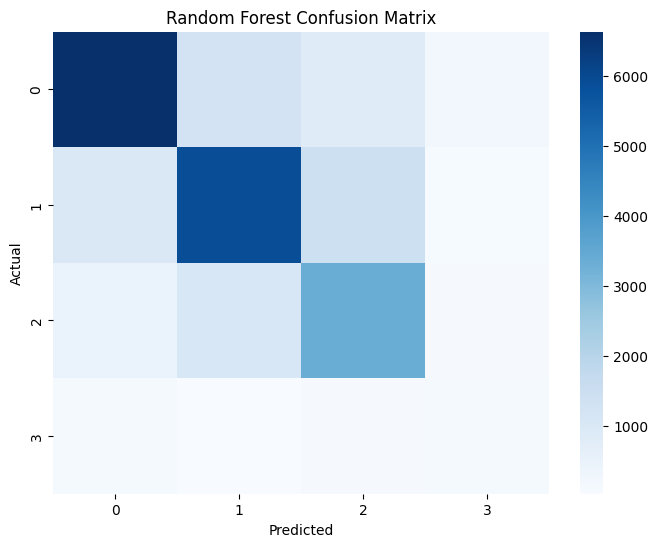

In [ ]:
#heatmap
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), cmap="Blues" )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

The confusion matrix reveals that the darkest cells—representing the highest concentration of predictions—are located in the upper left corner, particularly around (0,0). This suggests that a large portion of the dataset consists of songs with low popularity, leading to an overrepresentation of bin 0. As a result, the model is biased toward correctly predicting this class more frequently, which may skew overall performance metrics.

In contrast, the bottom right corner of the matrix is noticeably lighter, indicating that the model struggles to accurately classify songs with higher popularity. This could be attributed to fewer high-popularity samples or less distinctive feature patterns in those bins.

Despite this imbalance, there is a strong concentration along the diagonal, which shows that the model is generally assigning songs to the correct or nearby popularity bins, reflecting a reasonable level of predictive accuracy.

We will be dropping the songs with popularity score under 3 to rebalance our dataset.

In [ ]:
# from the exploratory data analysis above, we saw that the data is skewed
# with a majority of songs have a popularity score under 3
#dropping songs w pop score under 3

spotify_data_clean = spotify_data_clean[spotify_data_clean['popularity']>= 3]

# creating bins
spotify_data_clean['popularity_bin'] = pd.cut(
    spotify_data_clean['popularity'],
    bins= [0, 25, 50, 75, 100],
    labels=[f"bin_{i}" for i in range(4)],
    include_lowest = True
)

# Define features (X) and target variable (y)
X= spotify_data_clean[features]
y= spotify_data_clean['popularity_bin']

#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Logistic Regression

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

# Evaluation metrics
lr_acc = accuracy_score(y_pred, y_test)

print("Accuracy: %.0f%%"% (lr_acc*100))

<ipython-input-32-93d6aebc38ed>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spotify_data_clean['popularity_bin'] = pd.cut(


Accuracy: 44%


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#### Random Forest
rand_forest = RandomForestClassifier(n_estimators=120, max_depth=30,
                                     class_weight='balanced', random_state=42)

#fit
rand_forest.fit(X_train, y_train)

# Predict on the test set
y_pred = rand_forest.predict(X_test)

#get accuracy and confusion matrix
rf_acc = accuracy_score(y_pred, y_test)

print("Accuracy: %.0f%%"% (rf_acc*100))
print("Confusion Matrix:\n", (confusion_matrix(y_test, y_pred)))



Accuracy: 69%
Confusion Matrix:
 [[3751  914  367   86]
 [ 908 5662 1574  141]
 [ 239 1101 3535  205]
 [  18   49  203  208]]


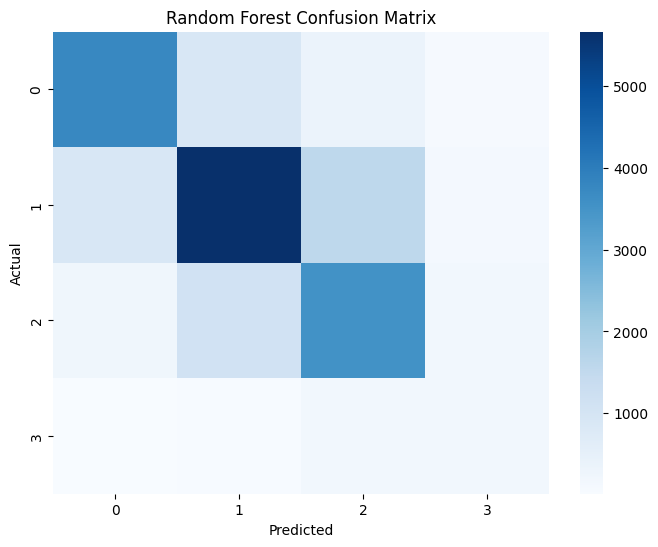

In [ ]:
#heatmap
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), cmap="Blues" )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

After removing songs with a popularity score under 3, the dataset became significantly more balanced. This preprocessing step led to a notable improvement in model performance, as evidenced by the confusion matrix.

The Random Forest classifier now demonstrates stronger diagonal dominance, indicating that the model is correctly classifying songs into the appropriate popularity bins. This reflects a meaningful improvement in the model's ability to distinguish between different levels of popularity.

Overall, this change helped reduce prediction bias toward low-popularity songs. The resulting predictions are also more accurate, achieving an accuracy of 69% compared to 39% with Logistic Regression.

**Brief Overview of Important Features**



<Axes: xlabel='Feature'>

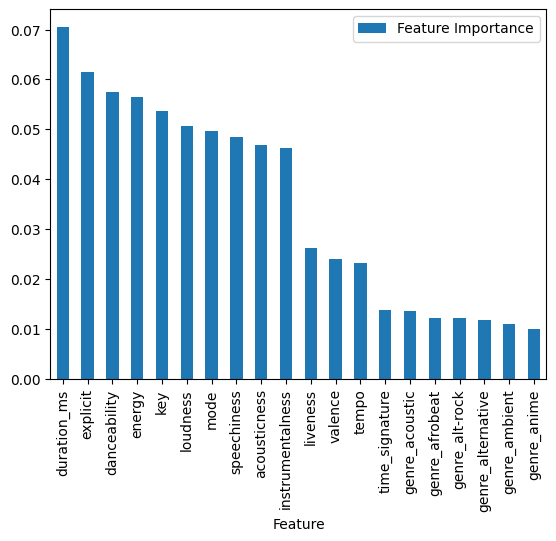

In [ ]:
#getting a brief overview of important features
feature_importance = rand_forest.feature_importances_

# TO-DO: Get the top 10 and Create a DataFrame `feature_importance_df`
feature_importance = np.sort(feature_importance)[::-1] #descending order

#convert to series
feature_importance = pd.Series(data = feature_importance, index=X_train.columns)

#get top 20
feature_importance = feature_importance.head(20)

#convert to dataframe
feature_importance_df = feature_importance.reset_index()
feature_importance_df = feature_importance_df.rename(columns={'index':'Feature',0:'Feature Importance'})

# TO-DO: Visualize the top 10 feature importance using a barplot
feature_importance_df.plot.bar(x='Feature',y='Feature Importance')


Our Random Forest analysis shows that track duration is the strongest driver of a song’s popularity, with the explicit label coming in a close second. Danceability and energy also rank highly, followed by musical attributes like key, loudness, and mode.

We can also conclude that genre plays an important role.

Next Steps: We will analyze how these top features behave within specific genres to uncover genre‑dependent patterns of success.

## **Testing Performance of multiple models: Logistic Regression, Random Forest, GradientBoosting, LightGBM, SVC, and MLP**

Having established that non-linear classifier models perform best in predicting a song's popularity bin, we decided to compare performance of Logistic Regression, Random Forest, Gradient Boost, Light GBM, SVC and MLP.

We compared their accuracy to determine the best model.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns


#dropping irrelevant columns and setting X and y vars
X = spotify_data_clean.drop(['popularity_bin','hit','popularity', 'track_id', 'artists', 'album_name', 'track_name', ''], axis=1, errors='ignore')
y = spotify_data_clean['popularity_bin']

#defining categorical and numeric features
categorical_features = ['explicit', 'key', 'mode', 'time_signature']
numeric_features = [col for col in X.columns if col not in categorical_features]

# setting preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.ensemble   import RandomForestClassifier, GradientBoostingClassifier
from lightgbm           import LGBMClassifier
from sklearn.svm        import SVC
from sklearn.neural_network import MLPClassifier

# Function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test, preprocessor):
    # Create pipeline with preprocessing and model
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train) #fit

    y_pred = pipeline.predict(X_test) #get predictions

    accuracy = accuracy_score(y_test, y_pred) #get accuracy

    # performing cross validation
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=1)
    cv_mean= cv_scores.mean()
    cv_std= cv_scores.std()

    return {
        'accuracy': accuracy,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'pipeline': pipeline
    }

#defining dictionary of models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boost': GradientBoostingClassifier(),
    'Light GBM': LGBMClassifier(random_state=42),
    'SVC': SVC(),
    'MLP': MLPClassifier(random_state=42)
}

results = {}  #dictionary for results


In [ ]:
#loop through each model
for name, model in models.items():
    print(f"Training {name}...")

    #store result in dict
    results[name] = evaluate_model(model, X_train, X_test, y_train, y_test, preprocessor)

    print(f"{name} - Accuracy: {results[name]['accuracy']:.4f}, "
    f"cv_mean: {results[name]['cv_mean']:.3f}, "
    f"cv_std: {results[name]['cv_std']:.3f}, ")

#get model with highest accuracy
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['pipeline']
best_acc = results[best_model_name]['accuracy']

print(f"\nBest model: {best_model_name} with accuracy = {best_acc:.4f}")


Training Logistic Regression...
Logistic Regression - Accuracy: 0.6647, cv_mean: 0.664, cv_std: 0.004, 
Training Random Forest...
Random Forest - Accuracy: 0.7364, cv_mean: 0.722, cv_std: 0.003, 
Training Gradient Boost...
Gradient Boost - Accuracy: 0.6510, cv_mean: 0.650, cv_std: 0.002, 
Training Light GBM...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053306 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2934
[LightGBM] [Info] Number of data points in the train set: 75843, number of used features: 145
[LightGBM] [Info] Start training from score -1.327448
[LightGBM] [Info] Start training from score -0.816493
[LightGBM] [Info] Start training from score -1.319227
[LightGBM] [Info] Start training from score -3.668041


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2934
[LightGBM] [Info] Number of data points in the train set: 60674, number of used features: 145
[LightGBM] [Info] Start training from score -1.327442
[LightGBM] [Info] Start training from score -0.816517
[LightGBM] [Info] Start training from score -1.319209
[LightGBM] [Info] Start training from score -3.667906


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Light GBM - Accuracy: 0.6958, cv_mean: 0.693, cv_std: 0.004, 
Training SVC...
SVC - Accuracy: 0.6927, cv_mean: 0.686, cv_std: 0.003, 
Training MLP...


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

MLP - Accuracy: 0.6863, cv_mean: 0.676, cv_std: 0.002, 

Best model: Random Forest with accuracy = 0.7364


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Our comparison shows that, of all the classifiers we tried, the Random Forest model delivers the strongest performance on our balanced data, **achieving 73.6% accuracy at assigning tracks to the correct popularity bin.**


## Feature Engineering with Random Forest

After running intial models on the dataset, we wanted to explore the possibility of new features created from existing ones and seeing their potential impact on the model. Since the dataset provides a plethora of columns for us to use, we found a multitude of interesting interactions that could potentially give more insight into the popularity of a song. Using Random Forest as our model since it was the best one from our analysis before, we will implement our featured engineering columns to a new random forest model and see how it compares to the original.

In [ ]:
spotify_data =spotify_data.drop(columns='Unnamed: 0')
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble   import RandomForestClassifier, GradientBoostingClassifier
from lightgbm           import LGBMClassifier
from sklearn.svm        import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score

In [ ]:
def create_simple_features(df):
    """
    Create a set of high-impact engineered features for music popularity prediction
    """
    # Create a copy of the dataframe
    df_new = df.copy()
     # Drop the unnamed column if it exists
    if '' in df_new.columns:
        df_new = df_new.drop('Unnamed: 0', axis=1)
    # 1. Energy and danceability interaction (popular songs often have both)
    df_new['energy_dance'] = df_new['energy'] * df_new['danceability']

    # 2. Loudness and energy combined (intensity measure)
    # First normalize loudness to positive values
    normalized_loudness = (df_new['loudness'] - df_new['loudness'].min()) / (df_new['loudness'].max() - df_new['loudness'].min())
    df_new['intensity'] = normalized_loudness * df_new['energy']

    # 3. Duration in minutes (simpler than milliseconds)
    df_new['duration_min'] = df_new['duration_ms'] / 60000

    # 4. Simple "radio friendly" flag (songs between 3-4 minutes)
    df_new['radio_friendly'] = ((df_new['duration_ms'] >= 180000) &
                               (df_new['duration_ms'] <= 240000)).astype(int)

    # 5. Mood indicator (combination of valence and energy)
    df_new['mood'] = df_new['valence'] * df_new['energy']

    # 6. Is the song explicit (convert to numeric)
    df_new['is_explicit'] = (df_new['explicit'] == 'True').astype(int)

    # 7. Acoustic vs electronic spectrum
    df_new['acoustic_electronic'] = df_new['acousticness'] - df_new['energy']

    # 8. Vocal character (speech vs instrumental)
    df_new['vocal_character'] = df_new['speechiness'] - df_new['instrumentalness']

    # 9. Squared features for non-linear relationships
    df_new['danceability_squared'] = df_new['danceability'] ** 2
    df_new['energy_squared'] = df_new['energy'] ** 2
    df_new['acousticness_squared'] = df_new['acousticness'] ** 2
    df_new['valence_squared'] = df_new['valence'] ** 2

    # 10. Tempo normalized to a more intuitive range (as BPM can vary widely)
    df_new['tempo_normalized'] = (df_new['tempo'] - df_new['tempo'].min()) / (df_new['tempo'].max() - df_new['tempo'].min())

    # 11. Simple tempo categories (slow, medium, fast)
    df_new['is_slow_tempo'] = (df_new['tempo'] < 90).astype(int)
    df_new['is_medium_tempo'] = ((df_new['tempo'] >= 90) & (df_new['tempo'] < 120)).astype(int)
    df_new['is_fast_tempo'] = (df_new['tempo'] >= 120).astype(int)

    # 12. Hit potential indicator (combination of features common in hits)
    df_new['hit_potential'] = ((df_new['energy'] > 0.7) &
                              (df_new['danceability'] > 0.6) &
                              (df_new['loudness'] > -8) &
                              (df_new['radio_friendly'] == 1)).astype(int)

    # 13. Danceability to tempo ratio (how dance-friendly relative to speed)
    df_new['dance_tempo_ratio'] = df_new['danceability'] / (df_new['tempo'] / 100)

    # 14. Valence to energy ratio (emotional content relative to energy)
    df_new['valence_energy_ratio'] = df_new['valence'] / (df_new['energy'] + 0.01)  # Adding 0.01 to avoid division by zero

    # 15. Log transformations for skewed features
    df_new['log_instrumentalness'] = np.log1p(df_new['instrumentalness'])
    df_new['log_speechiness'] = np.log1p(df_new['speechiness'])
    df_new['log_liveness'] = np.log1p(df_new['liveness'])
    df_new['log_acousticness'] = np.log1p(df_new['acousticness'])

    # 16. Energy variation (combines several energy-related features)
    df_new['energy_variation'] = df_new['energy'] * (1 - df_new['acousticness']) * normalized_loudness

    # 17. Cross-feature ratios
    df_new['speech_to_instrumental_ratio'] = df_new['speechiness'] / (df_new['instrumentalness'] + 0.01)
    df_new['energy_to_acoustic_ratio'] = df_new['energy'] / (df_new['acousticness'] + 0.01)

    # 18. Key and mode interaction (create a combined feature)
    df_new['key_mode'] = df_new['key'] * 2 + df_new['mode']  # Creates a unique value for each key+mode combination

    # 19. Complexity score (combination of features that suggest complexity)
    df_new['complexity'] = (df_new['speechiness'] +
                           (1 - df_new['acousticness']) +
                           df_new['instrumentalness'] +
                           df_new['liveness']) / 4

    # 20. Duration extremes flags
    df_new['is_very_short'] = (df_new['duration_min'] < 2).astype(int)
    df_new['is_very_long'] = (df_new['duration_min'] > 5).astype(int)

    # 21. Popularity potential score (weighted combination of key features)
    df_new['popularity_score'] = (
        0.3 * df_new['danceability'] +
        0.2 * df_new['energy'] +
        0.15 * normalized_loudness +
        0.1 * df_new['valence'] +
        0.1 * (1 - df_new['acousticness']) +
        0.15 * (df_new['radio_friendly'])
    )

    # 22. Feature interactions
    df_new['dance_valence'] = df_new['danceability'] * df_new['valence']
    df_new['energy_loudness'] = df_new['energy'] * normalized_loudness
    df_new['speech_live'] = df_new['speechiness'] * df_new['liveness']


    return df_new

#creating new features
df_engineered = create_simple_features(spotify_data_clean)

#storing original and engineered features as set
original_features = set(spotify_data_clean.columns)
engineered_features = set(df_engineered.columns)

#getting new features
new_features = engineered_features - original_features

#print new features
print("New features created:")
for feature in sorted(list(new_features)):
    print(f"- {feature}")

#setting X for original and engineered features
X_original = spotify_data_clean.drop(['popularity_bin','hit','popularity', 'track_id', 'artists', 'album_name', 'track_name', ''], axis=1, errors='ignore')
y = spotify_data_clean['popularity_bin']

X_engineered = df_engineered.drop(['popularity_bin','hit','popularity', 'track_id', 'artists', 'album_name', 'track_name', ''], axis=1, errors='ignore')

#splitting features into train and test sets
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X_original, y, test_size=0.2, random_state=42)
X_train_eng, X_test_eng, _, _ = train_test_split(X_engineered, y, test_size=0.2, random_state=42)

print("\nTraining models...")

#initializing RF classifier and fitting
rf_orig = RandomForestClassifier(random_state=42)
rf_orig.fit(X_train_orig, y_train)

#getting predictions, accuracy and f1 score
y_pred_orig = rf_orig.predict(X_test_orig)
accuracy_orig = accuracy_score(y_test, y_pred_orig)
f1_orig = f1_score(y_test, y_pred_orig, average='macro')

# applying same steps for engineered set
rf_eng = RandomForestClassifier(random_state=42)
rf_eng.fit(X_train_eng, y_train)
y_pred_eng = rf_eng.predict(X_test_eng)
accuracy_eng = accuracy_score(y_test, y_pred_eng)
f1_eng = f1_score(y_test, y_pred_eng, average='macro')

#printing results
print(f"\nRandom Forest Classifier with original features - Accuracy: {accuracy_orig:.4f}")
print(f"Random Forest Classifier with original features - F1 Score: {f1_orig:.4f}")
print(f"Random Forest  Classifier with engineered features - Accuracy: {accuracy_eng:.4f}")
print(f"Random Forest  Classifier with engineered features - F1 Score: {f1_eng:.4f}")
print(f"Improvement: {accuracy_eng - accuracy_orig:.4f} ({(accuracy_eng - accuracy_orig)/accuracy_orig*100:.1f}%)")

#creating dataframe with feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train_eng.columns,
    'Importance': rf_eng.feature_importances_
}).sort_values('Importance', ascending=False)

#printing the top 10 most important features
print("\nTop 10 most important features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")


New features created:
- acoustic_electronic
- acousticness_squared
- complexity
- dance_tempo_ratio
- dance_valence
- danceability_squared
- duration_min
- energy_dance
- energy_loudness
- energy_squared
- energy_to_acoustic_ratio
- energy_variation
- hit_potential
- intensity
- is_explicit
- is_fast_tempo
- is_medium_tempo
- is_slow_tempo
- is_very_long
- is_very_short
- key_mode
- log_acousticness
- log_instrumentalness
- log_liveness
- log_speechiness
- mood
- popularity_score
- radio_friendly
- speech_live
- speech_to_instrumental_ratio
- tempo_normalized
- valence_energy_ratio
- valence_squared
- vocal_character

Training models...

Random Forest Classifier with original features - Accuracy: 0.7349
Random Forest Classifier with original features - F1 Score: 0.6508
Random Forest  Classifier with engineered features - Accuracy: 0.7412
Random Forest  Classifier with engineered features - F1 Score: 0.6968
Improvement: 0.0063 (0.9%)

Top 10 most important features:
- speech_to_instrume

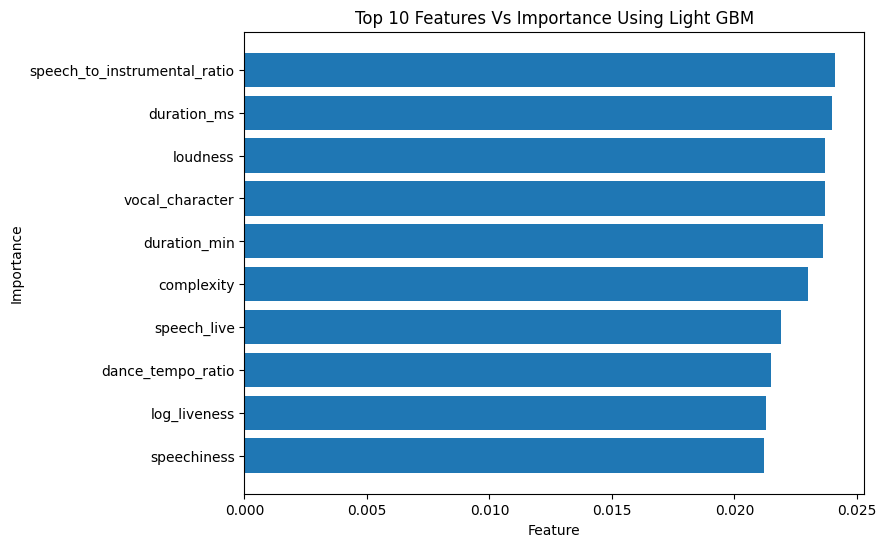

In [ ]:
#plotting results
#creating new df
results = {
    'Features': ['speech_to_instrumental_ratio', 'duration_ms', 'loudness', 'vocal_character',
        'duration_min', 'complexity', 'speech_live',
        'dance_tempo_ratio', 'log_liveness', 'speechiness'],
    'Importance': [0.0241, 0.0240,  0.0237, 0.0237, 0.0236, 0.0230, 0.0219,
                  0.0215, 0.0213, 0.0212]
}

top_10_features_df = pd.DataFrame(results)

#plot results
plt.figure(figsize=(8,6))
plt.barh(top_10_features_df['Features'][::-1], top_10_features_df['Importance'][::-1])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Top 10 Features Vs Importance Using Light GBM')
plt.show()

After developing new features, we observe a slight boost in model performance.

We can see that accuracy improved from 73.49% to 74.12% and that the F1 score also went from 65.08% to 69.68%.

We can also note that the most influentatial features are speech_to_instrumental_ratio, duration_ms:, loudness, vocal_character, duration_min, complexity.

## Model Stacking

In order to boost our best model's accuracy, we decided to stack multiple classifier models (Gradient Boost Classifier, Light GBM, SVC, MLP and Random Forest).

The goal is to see if a combination of robust models can help improve our accuracy of 73.6%.

In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier

# creating a list of models to stack
stacking_models = [
    ('GBoost', GradientBoostingClassifier(random_state=42)),
    ('LightGBM', LGBMClassifier(random_state=42)),
    ('SVC', SVC(class_weight='balanced', random_state=42)),
    ('MLP', MLPClassifier(random_state=42, max_iter=500)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                             random_state=42))
]

# creating stacking classifier
stacking = StackingClassifier(estimators= stacking_models,
                             passthrough=True)

stacking_pipeline= Pipeline([
    ('preprocessor', preprocessor),
    ('stacking', stacking)
])

#fitting
stacking_pipeline.fit(X_train, y_train)

#getting predictions and accuracy
y_pred = stacking_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052457 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2934
[LightGBM] [Info] Number of data points in the train set: 75843, number of used features: 145
[LightGBM] [Info] Start training from score -1.327448
[LightGBM] [Info] Start training from score -0.816493
[LightGBM] [Info] Start training from score -1.319227
[LightGBM] [Info] Start training from score -3.668041


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041299 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2934
[LightGBM] [Info] Number of data points in the train set: 60674, number of used features: 145
[LightGBM] [Info] Start training from score -1.327442
[LightGBM] [Info] Start training from score -0.816517
[LightGBM] [Info] Start training from score -1.319209
[LightGBM] [Info] Start training from score -3.667906


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041421 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2934
[LightGBM] [Info] Number of data points in the train set: 60675, number of used features: 145
[LightGBM] [Info] Start training from score -1.327458
[LightGBM] [Info] Start training from score -0.816496
[LightGBM] [Info] Start training from score -1.319225
[LightGBM] [Info] Start training from score -3.667922


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.086357 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2934
[LightGBM] [Info] Number of data points in the train set: 60675, number of used features: 145
[LightGBM] [Info] Start training from score -1.327458
[LightGBM] [Info] Start training from score -0.816496
[LightGBM] [Info] Start training from score -1.319225
[LightGBM] [Info] Start training from score -3.667922


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Accuracy: 0.75


We see that stacking multiple models together helps us slightly increase our accuracy from 73.6 to 75%.

## Stacked Model Per Genre

Given the results from our previous section, we decided to see whether our new stacked model's performance differs from one genre to the next.

By evaluating accuracy and F1 scores for each genre, we can identify which genres of music are most predictable.

In [ ]:
#getting all genre columns
genre_cols = [col for col in spotify_data_clean.columns if col.startswith('genre_')]

stacking_pipeline.fit(X_train, y_train)
y_pred_overall = stacking_pipeline.predict(X_test)

print("Printing overall accuracy: ",accuracy_score(y_pred, y_test))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053888 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2934
[LightGBM] [Info] Number of data points in the train set: 75843, number of used features: 145
[LightGBM] [Info] Start training from score -1.327448
[LightGBM] [Info] Start training from score -0.816493
[LightGBM] [Info] Start training from score -1.319227
[LightGBM] [Info] Start training from score -3.668041


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042318 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2934
[LightGBM] [Info] Number of data points in the train set: 60674, number of used features: 145
[LightGBM] [Info] Start training from score -1.327442
[LightGBM] [Info] Start training from score -0.816517
[LightGBM] [Info] Start training from score -1.319209
[LightGBM] [Info] Start training from score -3.667906


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

Genre:  trip-hop
Accuracy: 49%
F1 Score: 41%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Genre:  turkish
Accuracy: 94%
F1 Score: 32%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Genre:  world-music
Accuracy: 69%
F1 Score: 59%


In [ ]:
stacking_genre_df = [] #array to store results

# looping through the data and dropping nulls
for genre_col in genre_cols:
  genre = X_test[genre_col] ==1

  #defining features
  X_genre_test = X_test.loc[genre]
  y_genre_test = y_test.loc[genre]

  # Predict on the test set
  y_pred_genre = stacking_pipeline.predict(X_genre_test)

  #get accuracy and f1 score
  rf_acc = accuracy_score(y_genre_test, y_pred_genre)*100
  f1 = f1_score(y_genre_test, y_pred_genre, average='macro')*100

  stacking_genre_df.append({
      'Genre: ': genre_col.replace('genre_',''),
      'Accuracy: ': rf_acc,
      'F1: ': f1
  })

  #print result by genre
  print("Genre: ", genre_col.replace('genre_',''))
  print("Accuracy: %.0f%%"% (rf_acc))
  print("F1 Score: %.0f%%"% (f1))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Genre:  acoustic
Accuracy: 58%
F1 Score: 40%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Genre:  afrobeat
Accuracy: 65%
F1 Score: 29%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

Genre:  trip-hop
Accuracy: 49%
F1 Score: 41%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Genre:  turkish
Accuracy: 94%
F1 Score: 32%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Genre:  world-music
Accuracy: 69%
F1 Score: 59%


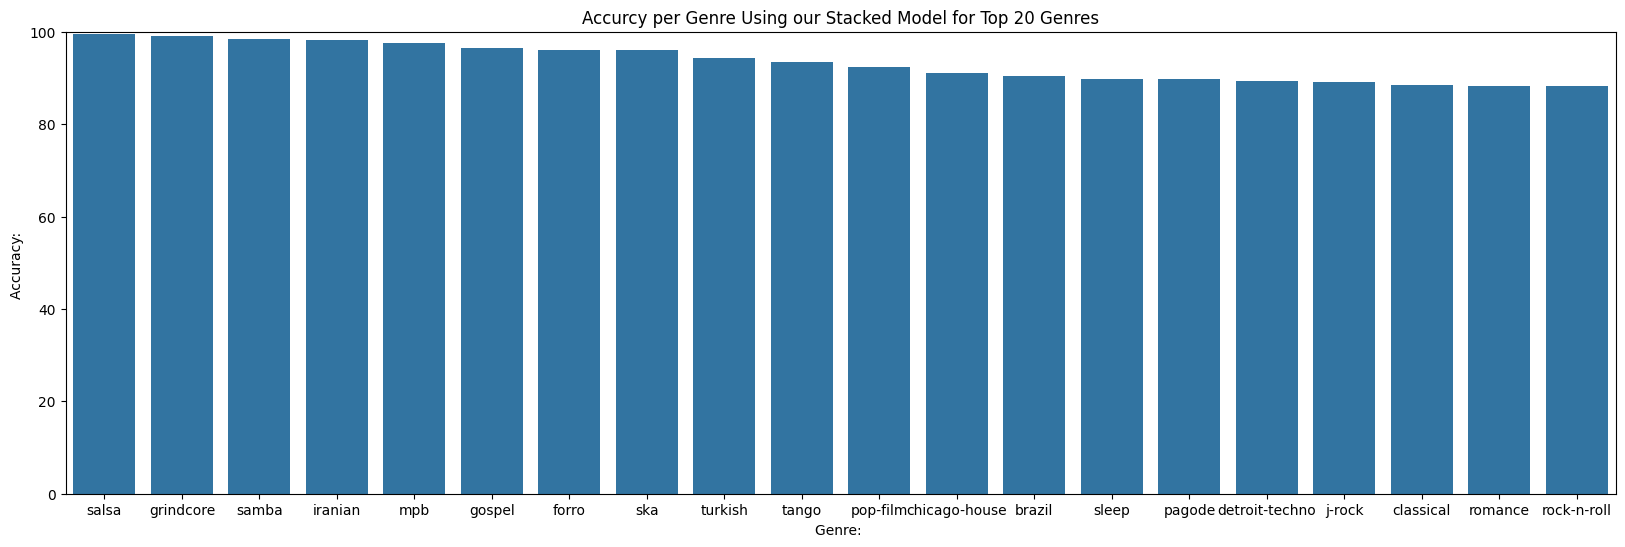

In [ ]:
# converting dict into df for visualizing
top_20_genres =pd.DataFrame(stacking_genre_df).sort_values(by=['Accuracy: '],ascending=False).head(20)
bottom_20_genres = pd.DataFrame(stacking_genre_df).sort_values(by=['Accuracy: '],ascending=True).head(20)

#plot genres with top accuracies
plt.figure(figsize=(20,6))
sns.barplot(data=top_20_genres, x="Genre: ", y="Accuracy: ")
plt.title("Accurcy per Genre Using our Stacked Model for Top 20 Genres")
plt.ylim(0,100)
plt.show()

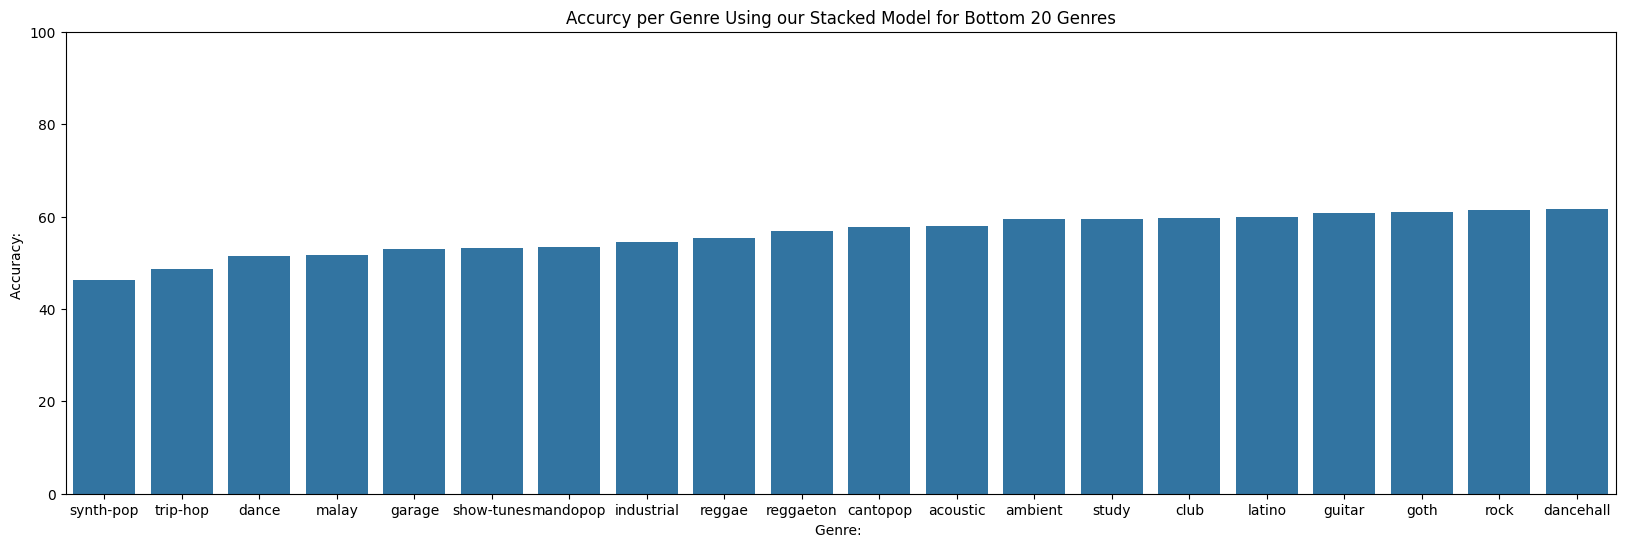

In [ ]:
# plot genres with lower accuracies
plt.figure(figsize=(20,6))
sns.barplot(data=bottom_20_genres, x="Genre: ", y="Accuracy: ")
plt.title("Accurcy per Genre Using our Stacked Model for Bottom 20 Genres")
plt.ylim(0,100)
plt.show()

Applying our stacked model to each genre reveals the wide disparity in performance. We can see that while some genres achieve accuracies of almost 100% like salsa or samba, others perform very poorly around 50% like synth-pop or reggae.

This suggests that our stacked model is struggling in identifying the features and characteristics that make low accuracy genres popular.


#**Challenges and Obstacles Faced**


Our project initially focused on predicting a song’s popularity as a continuous variable, using Spotify audio features and metadata. However, we quickly discovered that the popularity distribution was extremely skewed, with the vast majority of songs clustered in the lower range and only a small subset achieving high popularity. This imbalance posed significant problems for regression models, which struggled to generalize and often produced biased outputs toward the lower end.

To address this, we decided to bin the popularity scores into discrete categories (e.g., low, medium, high) and reframe the problem as a classification task. This pivot helped simplify the modeling objective and made the results more interpretable. However, it introduced a new set of challenges. First, defining meaningful and balanced bins was nontrivial — some binning strategies led to highly imbalanced classes, which reduced model performance and interpretability.

Additionally, while Spotify's audio features (such as energy, valence, and danceability) were rich, they did not always strongly correlate with popularity, likely because many influential factors — like marketing, artist reputation, or external trends — were not captured in the data. Finally, feature engineering and preprocessing were critical to manage multicollinearity and scale differences, which added complexity to our pipeline.

Despite these challenges, the pivot to classification ultimately allowed us to better explore which features most contributed to a song’s relative popularity tier.

While our final classification model achieved a maximum accuracy of around 75%, performance varied across classes, and results were limited by the inherent subjectivity and multi-dimensional nature of song popularity. Important factors such as  language, artist fanbase, cultural relevance, and timing of release were not captured in the dataset, making it difficult for our models to fully account for what drives a song’s success. As a result, while our model provided useful insights, its predictive capabilities were bounded by the scope of the features we had access to.



#**Next Steps and Future Directions**

Looking ahead, there are several promising directions for expanding and improving this project. First, we could incorporate additional features that more directly influence a song’s popularity, such as language, artist popularity, and release date. These variables often play a major role in how a song is promoted and received, and including them could enhance the model’s predictive power and interpretability.

Another avenue is to scrape or integrate external data sources, such as social media engagement metrics, YouTube view counts, TikTok trends, or streaming statistics from platforms beyond Spotify. These real-world indicators would provide a more holistic view of a song’s popularity and help capture the social and cultural context that influences listener behavior.

We also plan to experiment with more advanced classification techniques, including deep learning architectures, and hyperparameter tuning. These approaches could help address current limitations, particularly with class imbalance and overlapping feature distributions. Additionally, implementing class-specific performance metrics like precision, recall, and F1-score for each popularity bin would provide a clearer picture of model performance beyond overall accuracy.

Finally, we see potential in extending this analysis to recommendation systems, where the insights gained from predicting popularity could be used to suggest up-and-coming songs or help music producers understand trends in listener preferences.

